In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("telecom_ai_dataset.csv")

In [8]:
df.dropna(inplace=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['Clean_Text'],
    df['Sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [11]:
X = df['Clean_Text']
y = df['Sentiment']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [14]:
lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred = lr_model.predict(X_test_tfidf)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.725
              precision    recall  f1-score   support

    Negative       0.71      0.97      0.82       128
    Positive       0.84      0.29      0.43        72

    accuracy                           0.72       200
   macro avg       0.77      0.63      0.63       200
weighted avg       0.76      0.72      0.68       200



In [17]:
!pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.preprocessing import LabelEncoder

In [19]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df['Sentiment'])

In [20]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['Clean_Text'])

X_seq = tokenizer.texts_to_sequences(df['Clean_Text'])

In [21]:
X_pad = pad_sequences(X_seq, maxlen=100)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [23]:
lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))

lstm_model.add(LSTM(64))

lstm_model.add(Dense(32, activation='relu'))

lstm_model.add(Dense(1, activation='sigmoid'))

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [25]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7203 - loss: 0.6390 - val_accuracy: 0.6687 - val_loss: 0.6285
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7406 - loss: 0.5152 - val_accuracy: 0.6938 - val_loss: 0.5637
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8219 - loss: 0.3804 - val_accuracy: 0.7500 - val_loss: 0.5351
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9359 - loss: 0.2367 - val_accuracy: 0.7625 - val_loss: 0.6060
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9688 - loss: 0.1272 - val_accuracy: 0.7750 - val_loss: 0.6563


In [26]:
loss, accuracy = lstm_model.evaluate(X_test, y_test)

print("LSTM Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7700 - loss: 0.6847 
LSTM Accuracy: 0.7699999809265137


In [27]:
!pip install transformers datasets torch


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
import torch

In [29]:
import sys
print(sys.executable)

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Scripts\python.exe


In [30]:
df['label'] = df['Sentiment'].map({
    'Negative': 0,
    'Positive': 1
})

In [31]:
dataset = Dataset.from_pandas(
    df[['Clean_Text', 'label']]
)

In [32]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [33]:
def tokenize(batch):
    return tokenizer(
        batch['Clean_Text'],
        padding=True,
        truncation=True
    )

In [34]:
dataset = dataset.map(tokenize, batched=True)

Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8504.96 examples/s]


In [35]:
dataset = dataset.train_test_split(test_size=0.2)

In [36]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [37]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    
    num_train_epochs=2,
    
    per_device_train_batch_size=8,
    
    per_device_eval_batch_size=8,
    
    logging_dir="./logs",
    
    logging_steps=10,
    
    save_steps=100
)

In [38]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test']
)

In [39]:
trainer.train()

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.628700
20,0.622200
30,0.439100
40,0.539900
50,0.553400
60,0.475900
70,0.369400
80,0.438300
90,0.329900
100,0.303700


D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=200, training_loss=0.34963925302028653, metrics={'train_runtime': 934.5802, 'train_samples_per_second': 1.712, 'train_steps_per_second': 0.214, 'total_flos': 29391204076800.0, 'train_loss': 0.34963925302028653, 'epoch': 2.0})

In [40]:
trainer.evaluate()

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.3922331929206848,
 'eval_runtime': 39.497,
 'eval_samples_per_second': 5.064,
 'eval_steps_per_second': 0.633,
 'epoch': 2.0}

In [41]:
import os
import joblib
import tensorflow as tf

# --- STEP 0: Setup Directory ---
model_dir = r'D:\Guvi\Projects\Telecom_ai_brand_system\models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# --- STEP 1: Save Logistic Regression ---
# Ensure 'lr_model' exists
joblib.dump(lr_model, os.path.join(model_dir, 'logistic_regression_model.pkl'))

# --- STEP 2: Save LSTM ---
# Using the recommended .keras format to resolve the warning
lstm_model.save(os.path.join(model_dir, 'lstm_model.keras'))

# --- STEP 3: Save DistilBERT ---
# CRITICAL: Replace 'distilbert_model' with whatever variable you 
# used when calling DistilBertForSequenceClassification.from_pretrained(...)
try:
    distilbert_save_path = os.path.join(model_dir, 'distilbert_model')
    distilbert_model.save_pretrained(distilbert_save_path)
    tokenizer.save_pretrained(distilbert_save_path)
    print("All models saved successfully!")
except NameError as e:
    print(f"Error: {e}. Check if your model variable is named 'distilbert_model'.")

Error: name 'distilbert_model' is not defined. Check if your model variable is named 'distilbert_model'.


In [42]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("telecom_ai_dataset.csv")

# Encode labels
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['Sentiment'])

# Features and target
X = df['Clean_Text']

y = df['label']

# Check mapping
print(dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
)))

{'Negative': np.int64(0), 'Positive': np.int64(1)}


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [46]:
lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [48]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.725


In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.71      0.97      0.82       128
           1       0.84      0.29      0.43        72

    accuracy                           0.72       200
   macro avg       0.77      0.63      0.63       200
weighted avg       0.76      0.72      0.68       200



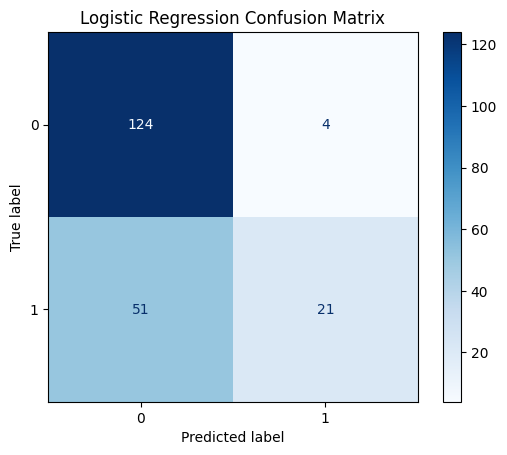

In [50]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)

disp.plot(cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [52]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

In [53]:
X_pad = pad_sequences(X_seq, maxlen=100)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=100
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(32, activation='relu'))

lstm_model.add(Dense(1, activation='sigmoid'))

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [56]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [57]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.7016 - loss: 0.6554 - val_accuracy: 0.6687 - val_loss: 0.6666
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7281 - loss: 0.5540 - val_accuracy: 0.6875 - val_loss: 0.5915
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8203 - loss: 0.4420 - val_accuracy: 0.7250 - val_loss: 0.5372
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9203 - loss: 0.2472 - val_accuracy: 0.7875 - val_loss: 0.5855
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9703 - loss: 0.1067 - val_accuracy: 0.7875 - val_loss: 0.6274


In [58]:
loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy:", lstm_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7750 - loss: 0.6399 
LSTM Accuracy: 0.7749999761581421


In [59]:
import numpy as np

y_pred_lstm = lstm_model.predict(X_test)

y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

y_pred_lstm = y_pred_lstm.flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step 


In [60]:
print(classification_report(y_test, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       128
           1       0.76      0.54      0.63        72

    accuracy                           0.78       200
   macro avg       0.77      0.72      0.74       200
weighted avg       0.77      0.78      0.76       200



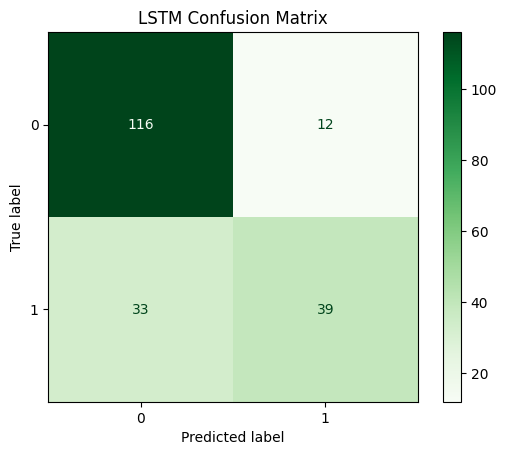

In [61]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)

disp.plot(cmap='Greens')

plt.title("LSTM Confusion Matrix")

plt.show()

In [62]:
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch

In [63]:
bert_df = df[['Clean_Text', 'label']]

dataset = Dataset.from_pandas(bert_df)

In [64]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [65]:
def tokenize(batch):
    return tokenizer(
        batch['Clean_Text'],
        padding=True,
        truncation=True
    )

In [66]:
dataset = dataset.map(tokenize, batched=True)

Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8980.84 examples/s]


In [67]:
dataset = dataset.train_test_split(test_size=0.2)

In [68]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [69]:
training_args = TrainingArguments(
    output_dir='./results',
    
    num_train_epochs=2,
    
    per_device_train_batch_size=8,
    
    per_device_eval_batch_size=8,
    
    logging_dir='./logs',
    
    logging_steps=10
)

In [70]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test']
)

In [ ]:
trainer.train()

D:\Guvi\Projects\Telecom_ai_brand_system\telecom\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.600600
20,0.657300
30,0.534900
40,0.633700
50,0.469100
60,0.448200
70,0.435600
80,0.407500
90,0.433600
100,0.399300


In [ ]:
predictions = trainer.predict(dataset['test'])

y_pred_bert = predictions.predictions.argmax(axis=1)

y_true_bert = predictions.label_ids

In [ ]:
from sklearn.metrics import accuracy_score

bert_accuracy = accuracy_score(
    y_true_bert,
    y_pred_bert
)

print("DistilBERT Accuracy:", bert_accuracy)

In [ ]:
print(classification_report(
    y_true_bert,
    y_pred_bert
))

In [ ]:
cm_bert = confusion_matrix(
    y_true_bert,
    y_pred_bert
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert)

disp.plot(cmap='Oranges')

plt.title("DistilBERT Confusion Matrix")

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'LSTM',
        'DistilBERT'
    ],
    
    'Accuracy': [
        lr_accuracy,
        lstm_accuracy,
        bert_accuracy
    ]
})

comparison_df

In [ ]:
comparison_df.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.show()

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "models/distilbert_model"
)

print(model.config.id2label)

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
print(sys.executable)

import accelerate
print("Accelerate:", accelerate.__version__)

import transformers
print("Transformers:", transformers.__version__)

In [ ]:
import torch
print(torch.__version__)

In [ ]:
from transformers.utils import is_torch_available
print(is_torch_available())2.12.0

In [ ]:
pip show torch

In [ ]:
import torch
import accelerate
import transformers

print("Torch:", torch.__version__)
print("Accelerate:", accelerate.__version__)
print("Transformers:", transformers.__version__)

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./results",
    report_to="none"
)

print("TrainingArguments working")